# CNN Classificacao Academica


In [1]:
import os, numpy as np, tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
dataset_path='dataset/chest_xray'
IMG_SIZE=(224,224)
BATCH_SIZE=32


In [3]:
train_gen=ImageDataGenerator(rescale=1./255).flow_from_directory(os.path.join(dataset_path,'train'),target_size=IMG_SIZE,batch_size=BATCH_SIZE,class_mode='binary')
val_gen=ImageDataGenerator(rescale=1./255).flow_from_directory(os.path.join(dataset_path,'val'),target_size=IMG_SIZE,batch_size=BATCH_SIZE,class_mode='binary')
test_gen=ImageDataGenerator(rescale=1./255).flow_from_directory(os.path.join(dataset_path,'test'),target_size=IMG_SIZE,batch_size=BATCH_SIZE,class_mode='binary',shuffle=False)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [4]:
cnn=Sequential([Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),MaxPooling2D(2,2),Conv2D(64,(3,3),activation='relu'),MaxPooling2D(2,2),Flatten(),Dense(128,activation='relu'),Dropout(0.5),Dense(1,activation='sigmoid')])
cnn.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
cnn.fit(train_gen,validation_data=val_gen,epochs=3,steps_per_epoch=20,validation_steps=1)


C:\Users\muril\Desktop\Fiap\2026\fase4\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.6609 - loss: 1.8476 - val_accuracy: 0.5625 - val_loss: 0.6087
Epoch 2/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.8219 - loss: 0.3952 - val_accuracy: 0.6250 - val_loss: 0.5942
Epoch 3/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9094 - loss: 0.2540 - val_accuracy: 0.6250 - val_loss: 0.9676


In [5]:
pred=(cnn.predict(test_gen)>0.5).astype(int)
print(classification_report(test_gen.classes,pred))
print(confusion_matrix(test_gen.classes,pred))


20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 789ms/step
              precision    recall  f1-score   support

           0       0.98      0.19      0.32       234
           1       0.67      1.00      0.80       390

    accuracy                           0.69       624
   macro avg       0.82      0.59      0.56       624
weighted avg       0.79      0.69      0.62       624

[[ 44 190]
 [  1 389]]


In [6]:
base=MobileNetV2(weights='imagenet',include_top=False,input_shape=(224,224,3))
base.trainable=False
x=GlobalAveragePooling2D()(base.output)
out=Dense(1,activation='sigmoid')(x)
model=Model(base.input,out)
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(train_gen,validation_data=val_gen,epochs=3,steps_per_epoch=20,validation_steps=1)


Epoch 1/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.6828 - loss: 0.5932 - val_accuracy: 0.5625 - val_loss: 0.7915
Epoch 2/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 970ms/step - accuracy: 0.8547 - loss: 0.3588 - val_accuracy: 0.6250 - val_loss: 0.6832
Epoch 3/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 965ms/step - accuracy: 0.9109 - loss: 0.2581 - val_accuracy: 0.5625 - val_loss: 0.5659


In [7]:
pred_tl=(model.predict(test_gen)>0.5).astype(int)
print(classification_report(test_gen.classes,pred_tl))
print(confusion_matrix(test_gen.classes,pred_tl))


20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 882ms/step
              precision    recall  f1-score   support

           0       0.96      0.46      0.62       234
           1       0.75      0.99      0.85       390

    accuracy                           0.79       624
   macro avg       0.85      0.72      0.74       624
weighted avg       0.83      0.79      0.77       624

[[108 126]
 [  5 385]]


In [8]:

from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np

def predizer_imagem(caminho):
    img = load_img(caminho, target_size=(224,224))

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    x = img_to_array(img)/255.0
    x = np.expand_dims(x, axis=0)

    prob = model.predict(x, verbose=0)[0][0]

    if prob > 0.5:
        resultado = "PNEUMONIA"
        confianca = prob * 100
    else:
        resultado = "NORMAL"
        confianca = (1 - prob) * 100

    print(f"Resultado: {resultado}")
    print(f"Confiança: {confianca:.2f}%")


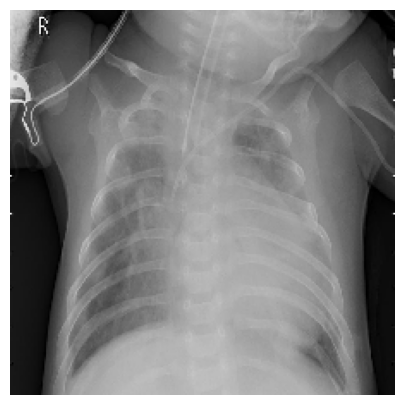

Resultado: PNEUMONIA
Confiança: 89.19%


In [9]:
predizer_imagem(
    "dataset/chest_xray/test/PNEUMONIA/person1_virus_6.jpeg"
)